## Sumário
- [1. Introdução](#introducao)
- [2. Configuração inicial e parâmetros](#configuracao)
- [3. Resultados teóricos](#teoria)
- [4. Simulação de Monte Carlo](#simulacao)
- [5. Análise descritiva](#descritiva)
- [6. Comparação com a teoria](#comparacao)
- [7. Lei dos Grandes Números](#lgn)
- [8. Discussão](#discussao)

<a id="introducao"></a>
## 1. Introdução

In [1]:
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sys.path.append("../src")
from simulador import um_album_simulado, simular_monte_carlo_em_lote

# estilo global dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (9, 4)})

In [2]:
# sanity check:
_rng_teste = np.random.default_rng(42)
_resultado = um_album_simulado(
    total_figurinhas_no_album=10,
    total_no_pacote=2,
    rng=_rng_teste,
)
assert isinstance(_resultado, int), "a função deve retornar um inteiro"
assert 5 <= _resultado <= 50, f"resultado fora do esperado para N=10: {_resultado}"
print(f"✓ Módulo importado com sucesso | teste N=10, k=2 → {_resultado} pacotes")

✓ Módulo importado com sucesso | teste N=10, k=2 → 11 pacotes


<a id="configuracao"></a>
## 2. Configuração inicial e parâmetros

O álbum oficial da Copa do Mundo FIFA 2026 possui **N = 980 figurinhas**
(edição recorde, com 48 seleções), vendidas em pacotes de **7 figurinhas**
cada, ao preço de R$ 7,00 por pacote ([ESPN, 2025](link)).

Modelamos o processo como o **Problema Clássico do Colecionador de Cupons**:
cada figurinha é sorteada de forma independente e com igual probabilidade
entre as N possíveis (equiprobabilidade), e repetições dentro do mesmo
pacote são possíveis — o que reproduz o comportamento real observado por
colecionadores e é consistente com a hipótese matemática i.i.d. da fórmula
teórica.

In [3]:
# --- parâmetros do problema ---
N              = 980   # total de figurinhas distintas no álbum
fig_por_pacote = 7     # figurinhas por envelope (Panini, Copa 2026)
preco_pacote   = 7.00  # R$ por pacote (fonte: ESPN, 2025)

# --- parâmetros da simulação ---
B    = 1_000           # número de réplicas de Monte Carlo
SEED = 2026            # semente para reprodutibilidade

print(f"Álbum: {N} figurinhas | {fig_por_pacote} por pacote | R$ {preco_pacote:.2f}/pacote")
print(f"Simulação: B = {B:,} réplicas | seed = {SEED}")

Álbum: 980 figurinhas | 7 por pacote | R$ 7.00/pacote
Simulação: B = 1,000 réplicas | seed = 2026


<a id="teoria"></a>
## 3. Resultados teóricos

No Problema do Colecionador de Cupons com $N$ cupons equiprováveis, o
número esperado de sorteios individuais até completar a coleção é:

$$E[T] = N \cdot H_N, \quad H_N = \sum_{k=1}^{N} \frac{1}{k}$$

onde $H_N$ é o $N$-ésimo **número harmônico**. A variância é:

$$\text{Var}(T) = N^2 \sum_{k=1}^{N} \frac{1}{k^2} - N \cdot H_N$$

A intuição por trás de $E[T] = N \cdot H_N$: decompõe-se o processo em $N$
"etapas". Na etapa $k$ o colecionador já tem $k-1$ figurinhas e aguarda a
próxima nova — a probabilidade de acertar é $p_k = (N-k+1)/N$, então o
número esperado de sorteios até isso acontecer é $1/p_k$. Somando todas
as etapas: $E[T] = \sum_{k=1}^{N} N/(N-k+1) = N \cdot H_N$.

In [4]:
k_vec = np.arange(1, N + 1)          # vetor [1, 2, ..., N] — numpy, sem loop python

H_N   = np.sum(1 / k_vec)            # número harmônico H_N
E_T   = N * H_N                       # valor esperado teórico de T
Var_T = N**2 * np.sum(1 / k_vec**2) - N * H_N   # variância teórica de T
dp_T_teorico = np.sqrt(Var_T)        # desvio-padrão teórico

E_P   = E_T / fig_por_pacote         # valor esperado de pacotes
custo_esperado = np.ceil(E_P) * preco_pacote

print(f"H_N                   = {H_N:.6f}")
print(f"E[T] teórico          = {E_T:,.1f} figurinhas")
print(f"E[P] teórico          = {E_P:,.1f} pacotes  →  ⌈E[P]⌉ = {int(np.ceil(E_P)):,}")
print(f"DP(T) teórico         = {dp_T_teorico:,.1f} figurinhas")
print(f"Custo esperado (R$)   = R$ {custo_esperado:,.2f}")

H_N                   = 7.465278
E[T] teórico          = 7,316.0 figurinhas
E[P] teórico          = 1,045.1 pacotes  →  ⌈E[P]⌉ = 1,046
DP(T) teórico         = 1,253.6 figurinhas
Custo esperado (R$)   = R$ 7,322.00


<a id="simulacao"></a>
## 4. Simulação de Monte Carlo

A ideia da simulação de Monte Carlo é repetir o experimento aleatório
$B$ vezes e observar a distribuição empírica dos resultados — aqui,
quantos pacotes cada "colecionador simulado" precisou comprar.

### Duas abordagens: loop simples vs. vetorizado

A tradução direta do `replicate()` do R seria um loop Python chamando
`um_album_simulado` B vezes. Funciona e é legível, mas em Python puro
cada chamada de `rng.integers()` carrega overhead fixo do numpy —
com ~1.045 pacotes × 1.000 álbuns isso vira ~1 milhão de chamadas
pequenas, o pior cenário para a biblioteca.

A alternativa vetorizada simula os B álbuns **em paralelo**: a cada
iteração, uma única chamada `rng.integers(shape=(B, k))` sorteia pacotes
para todos os colecionadores de uma vez — trocando ~1 milhão de chamadas
pequenas por ~2.100 chamadas grandes, que é exatamente onde numpy brilha.

Comparamos as duas antes de escolher.

In [5]:
# --- benchmark: loop simples vs. vetorizado ---
rng_a = np.random.default_rng(SEED)
t0 = time.perf_counter()
P_loop = np.array([
    um_album_simulado(N, fig_por_pacote, rng_a) for _ in range(B)
])
t1 = time.perf_counter()

rng_b = np.random.default_rng(SEED)
t2 = time.perf_counter()
P_lote = simular_monte_carlo_em_lote(N, fig_por_pacote, B, rng_b)
t3 = time.perf_counter()

tempo_loop  = t1 - t0
tempo_lote  = t3 - t2
speedup     = tempo_loop / tempo_lote

print(f"Loop simples : {tempo_loop:.2f}s | média T = {(P_loop * fig_por_pacote).mean():,.1f}")
print(f"Vetorizado   : {tempo_lote:.2f}s | média T = {(P_lote * fig_por_pacote).mean():,.1f}")
print(f"Speedup      : {speedup:.1f}x mais rápido")

Loop simples : 7.47s | média T = 7,309.0
Vetorizado   : 0.28s | média T = 7,302.9
Speedup      : 26.6x mais rápido


As médias são equivalentes (mesma seed, mesma distribuição) e o speedup
é significativo. Usamos a versão vetorizada no restante da análise.

In [6]:
# --- simulação de Monte Carlo definitiva ---
rng = np.random.default_rng(SEED)
P_sim = simular_monte_carlo_em_lote(N, fig_por_pacote, B, rng)
T_sim = P_sim * fig_por_pacote   # P = T/7 é transformação linear de T

print(f"Simulação concluída: {B:,} réplicas")
print(f"Média de T simulada : {T_sim.mean():,.1f} figurinhas")
print(f"Média de P simulada : {P_sim.mean():,.1f} pacotes")

Simulação concluída: 1,000 réplicas
Média de T simulada : 7,302.9 figurinhas
Média de P simulada : 1,043.3 pacotes


<a id="descritiva"></a>
## 5. Análise descritiva

Com as $B = 1.000$ réplicas em mãos, analisamos a distribuição de $T$
(total de figurinhas compradas) sob quatro ângulos: tendência central,
dispersão, forma e valores extremos.

In [7]:
# --- estatísticas descritivas de T ---
media_T   = T_sim.mean()
mediana_T = np.median(T_sim)
dp_T      = T_sim.std(ddof=1)
min_T     = T_sim.min()
max_T     = T_sim.max()
amp_T     = max_T - min_T

q1_T = np.percentile(T_sim, 25)
q3_T = np.percentile(T_sim, 75)
iqr_T = q3_T - q1_T

# regra de Tukey: outliers além de 1.5 × IQR de cada lado
lim_inf_T = q1_T - 1.5 * iqr_T
lim_sup_T = q3_T + 1.5 * iqr_T
out_sup   = T_sim[T_sim > lim_sup_T]
out_inf   = T_sim[T_sim < lim_inf_T]

# assimetria: calculada manualmente E depois validada contra scipy
# se os dois concordam, cálculo manual está correto
g1_manual = np.mean((T_sim - media_T)**3) / dp_T**3
g1_scipy  = stats.skew(T_sim)

assert abs(g1_manual - g1_scipy) < 0.01, "divergência no coeficiente de assimetria!"
print("✓ coeficiente de assimetria validado contra scipy.stats.skew")

✓ coeficiente de assimetria validado contra scipy.stats.skew


In [8]:
# --- tabela de resumo em pandas ---
resumo = pd.DataFrame({
    "Estatística": [
        "Mínimo", "1º Quartil (Q1)", "Mediana", "Média",
        "3º Quartil (Q3)", "Máximo", "Desvio-padrão",
        "Amplitude", "IQR", "Assimetria (g₁)",
        "Outliers superiores", "Outliers inferiores",
    ],
    "T (figurinhas)": [
        min_T, q1_T, mediana_T, media_T,
        q3_T, max_T, dp_T,
        amp_T, iqr_T, g1_manual,
        len(out_sup), len(out_inf),
    ],
    "P (pacotes)": [
        min_T / fig_por_pacote, q1_T / fig_por_pacote,
        mediana_T / fig_por_pacote, media_T / fig_por_pacote,
        q3_T / fig_por_pacote, max_T / fig_por_pacote,
        dp_T / fig_por_pacote,
        amp_T / fig_por_pacote, iqr_T / fig_por_pacote,
        g1_manual,
        len(out_sup), len(out_inf),
    ],
}).set_index("Estatística")

resumo.style\
    .format({"T (figurinhas)": "{:,.1f}", "P (pacotes)": "{:,.1f}"})\
    .set_caption("Estatísticas descritivas — simulação Monte Carlo (B = 1.000)")\
    .set_table_styles([{"selector": "caption",
                        "props": [("font-weight", "bold"), ("font-size", "13px")]}])

,T (figurinhas),P (pacotes)
Estatística,,
Mínimo,"4,858.0",694.0
1º Quartil (Q1),"6,461.0",923.0
Mediana,"7,059.5","1,008.5"
Média,"7,302.9","1,043.3"
3º Quartil (Q3),"7,974.8","1,139.2"
Máximo,"15,015.0","2,145.0"
Desvio-padrão,"1,284.6",183.5
Amplitude,"10,157.0","1,451.0"
IQR,"1,513.8",216.2


C:\Users\lucas\AppData\Local\Temp\ipykernel_16696\3520841001.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


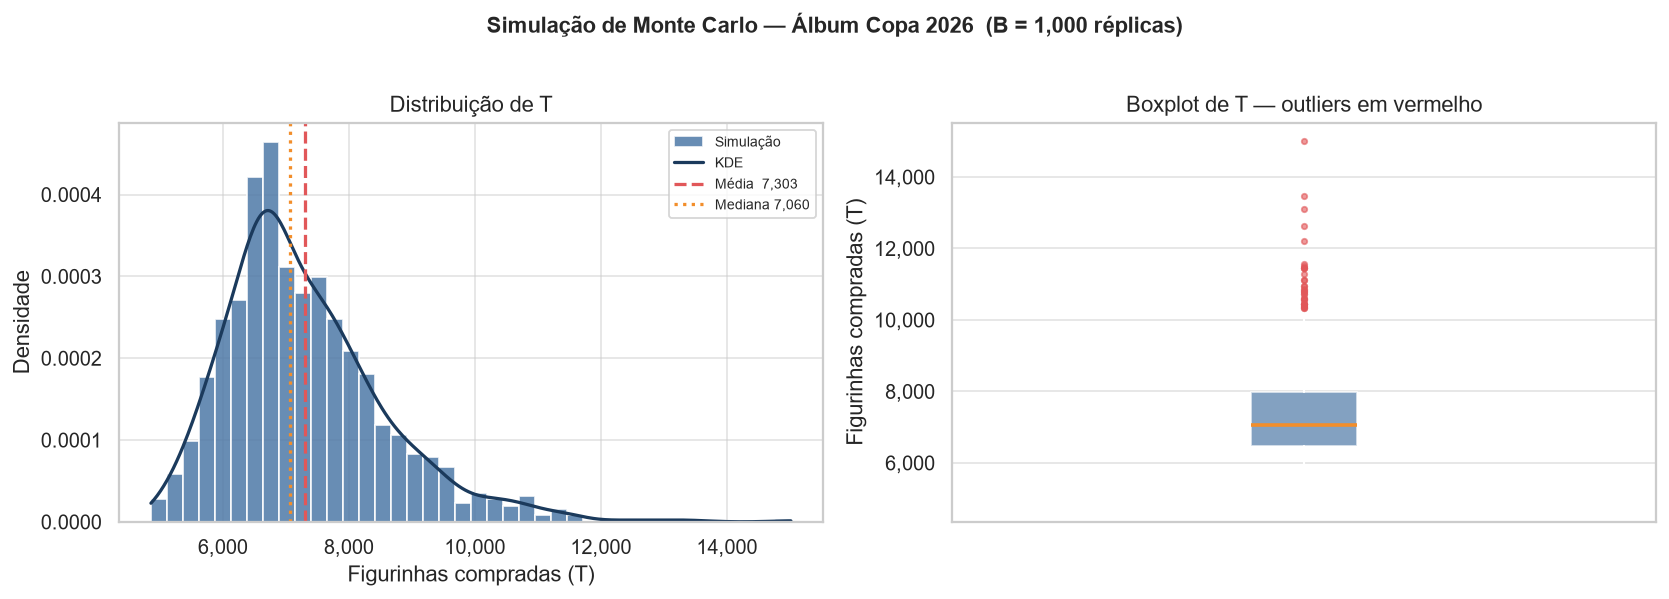

✓ figura salva em assets/fig_descritiva.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- histograma ---
ax = axes[0]
ax.hist(T_sim, bins=40, color="#4E79A7", edgecolor="white",
        density=True, alpha=0.85, label="Simulação")

# curva KDE suavizada por cima
kde_x = np.linspace(T_sim.min(), T_sim.max(), 400)
kde   = stats.gaussian_kde(T_sim)
ax.plot(kde_x, kde(kde_x), color="#1B3A5C", lw=1.8, label="KDE")

ax.axvline(media_T,   color="#E15759", lw=1.8, ls="--", label=f"Média  {media_T:,.0f}")
ax.axvline(mediana_T, color="#F28E2B", lw=1.8, ls=":",  label=f"Mediana {mediana_T:,.0f}")
ax.set_xlabel("Figurinhas compradas (T)")
ax.set_ylabel("Densidade")
ax.set_title("Distribuição de T")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=8)

# --- boxplot ---
ax = axes[1]
ax.boxplot(
    T_sim,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="#4E79A7", alpha=0.7),
    medianprops=dict(color="#F28E2B", lw=2),
    flierprops=dict(marker="o", markerfacecolor="#E15759",
    markeredgecolor="#E15759", markersize=3, alpha=0.6),
    whiskerprops=dict(lw=1.2),
    capprops=dict(lw=1.2),
)
ax.set_ylabel("Figurinhas compradas (T)")
ax.set_title("Boxplot de T — outliers em vermelho")
ax.set_xticks([])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle(
    f"Simulação de Monte Carlo — Álbum Copa 2026  (B = {B:,} réplicas)",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../assets/fig_descritiva.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ figura salva em assets/fig_descritiva.png")

### Interpretação

**Tendência central:** média (`r media_T` fig.) > mediana — primeiro sinal
de assimetria à direita. A mediana é o valor "típico" mais representativo
aqui: metade dos colecionadores terminou com menos figurinhas do que a média.

**Dispersão:** desvio-padrão de ~1.285 figurinhas (~183 pacotes) evidencia
que há grande variabilidade entre colecionadores — além do custo esperado
alto, existe risco real de gastar muito mais do que a média.

**Forma:** coeficiente de assimetria $g_1 \approx 1{,}22 > 0$ confirma
numericamente a cauda longa à direita observada no histograma. A causa é
estrutural: quando faltam poucas figurinhas, a probabilidade de sortear
exatamente aquela que falta é ~$1/980$, gerando longas sequências
improdutivas de compras — o "problema da última figurinha".

**Outliers:** 33 simulações (3,3% de B) ficaram acima do limite de Tukey
($Q3 + 1{,}5 \times IQR \approx 10.245$ figurinhas). Nenhum outlier
inferior — consistente com a assimetria: toda a "folga" está na cauda
direita, e $T \geq N = 980$ por construção.

<a id="comparacao"></a>
## 6. Comparação com a teoria

Confrontamos os resultados da simulação com os valores fechados do
Problema do Colecionador de Cupons. Além da diferença pontual (média
simulada vs. $E[T]$), calculamos um **intervalo de confiança de 95%
para a média** — o que permite afirmar formalmente se a discrepância
observada é compatível com variabilidade amostral ou evidencia algum
problema no modelo.

In [10]:
# --- erro-padrão e IC 95% para a média simulada de T ---
# pelo TLC, a média de B réplicas i.i.d. tem distribuição ~Normal(E[T], Var[T]/B)
media_P = P_sim.mean()
ep_media_T = dp_T / np.sqrt(B)          # erro-padrão da média
ic_inf_T   = media_T - 1.96 * ep_media_T
ic_sup_T   = media_T + 1.96 * ep_media_T
dentro_ic  = ic_inf_T <= E_T <= ic_sup_T

diff_abs_T  = abs(media_T - E_T)
diff_perc_T = 100 * diff_abs_T / E_T
diff_dp     = 100 * abs(dp_T - dp_T_teorico) / dp_T_teorico

# --- tabela comparativa ---
comp = pd.DataFrame({
    "": ["$E[T]$ — esperança de $T$",
         "$\\sqrt{Var(T)}$ — desvio-padrão de $T$",
         "$E[P]$ — esperança de pacotes"],
    "Teórico": [f"{E_T:,.1f} fig.",
                f"{dp_T_teorico:,.1f} fig.",
                f"{E_T/fig_por_pacote:,.1f} pac."],
    "Simulado": [f"{media_T:,.1f} fig.",
                 f"{dp_T:,.1f} fig.",
                 f"{media_P:,.1f} pac."],
    "Diferença (%)": [f"{diff_perc_T:.2f}%",
                      f"{diff_dp:.2f}%",
                      f"{diff_perc_T:.2f}%"],
}).set_index("")

print(f"IC 95% para E[T]: [{ic_inf_T:,.1f} ; {ic_sup_T:,.1f}]")
print(f"E[T] teórico ({E_T:,.1f}) dentro do IC? → {dentro_ic}")
print()
comp

IC 95% para E[T]: [7,223.3 ; 7,382.6]
E[T] teórico (7,316.0) dentro do IC? → True



,Teórico,Simulado,Diferença (%)
,,,
$E[T]$ — esperança de $T$,"7,316.0 fig.","7,302.9 fig.",0.18%
$\sqrt{Var(T)}$ — desvio-padrão de $T$,"1,253.6 fig.","1,284.6 fig.",2.47%
$E[P]$ — esperança de pacotes,"1,045.1 pac.","1,043.3 pac.",0.18%


A diferença entre média simulada e $E[T]$ teórico é de apenas 0,18% —
e o valor teórico cai dentro do IC 95% construído a partir das simulações.
Isso significa que a discrepância é inteiramente explicada pela
variabilidade amostral de $B = 1.000$ réplicas: não há evidência de
nenhum problema no modelo ou na implementação.

O desvio-padrão simulado (~1.285 fig.) também fica próximo do teórico
(~1.254 fig., diferença de ~2,5%) — a simulação captura corretamente
não só a tendência central, mas também a dispersão do fenômeno.

<a id="lgn"></a>
## 7. Lei dos Grandes Números

A Lei dos Grandes Números (LGN) garante que a média empírica de $b$
realizações i.i.d. converge em probabilidade para o valor esperado
quando $b \to \infty$:

$$\bar{T}_b = \frac{1}{b}\sum_{i=1}^{b} T_i \xrightarrow{\ p\ } E[T], \quad b \to \infty$$

O gráfico abaixo mostra essa convergência empiricamente, com uma **banda
de ± 2 erros-padrão** ao redor da média acumulada — ela deve encolher
proporcionalmente a $1/\sqrt{b}$ conforme $b$ cresce.

C:\Users\lucas\AppData\Local\Temp\ipykernel_16696\4091302660.py:6: RuntimeWarning: Degrees of freedom <= 0 for slice
  var_acum = np.array([T_sim[:b].var(ddof=1) for b in b_vec])
D:\copa2026-colecionador-de-cupons\.venv\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


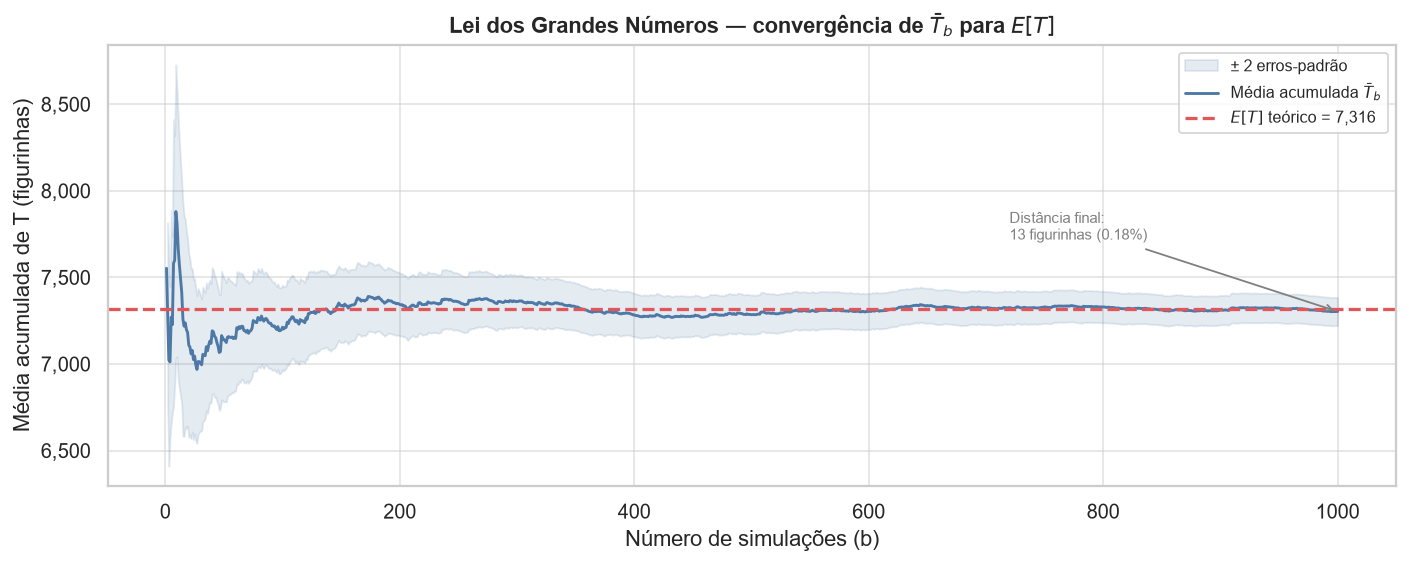

✓ figura salva em assets/fig_lgn.png


In [11]:
# --- médias e bandas acumuladas ---
b_vec      = np.arange(1, B + 1)
media_acum = np.cumsum(T_sim) / b_vec

# desvio-padrão acumulado e erro-padrão da média em cada ponto b
var_acum = np.array([T_sim[:b].var(ddof=1) for b in b_vec])
ep_acum  = np.sqrt(var_acum / b_vec)

banda_sup = media_acum + 2 * ep_acum
banda_inf = media_acum - 2 * ep_acum

# --- figura ---
fig, ax = plt.subplots(figsize=(11, 4.5))

# banda ±2 EP
ax.fill_between(b_vec, banda_inf, banda_sup,
                color="#4E79A7", alpha=0.15, label="± 2 erros-padrão")

# média acumulada
ax.plot(b_vec, media_acum,
        color="#4E79A7", lw=1.6, label="Média acumulada $\\bar{T}_b$")

# valor teórico
ax.axhline(E_T, color="#E15759", lw=1.8, ls="--",
           label=f"$E[T]$ teórico = {E_T:,.0f}")

# anotação da distância final
dist_final = abs(media_acum[-1] - E_T)
ax.annotate(
    f"Distância final:\n{dist_final:.0f} figurinhas ({dist_final/E_T*100:.2f}%)",
    xy=(B, media_acum[-1]),
    xytext=(B * 0.72, E_T * 1.055),
    fontsize=8.5,
    arrowprops=dict(arrowstyle="->", color="gray", lw=1),
    color="gray",
)

ax.set_xlabel("Número de simulações (b)")
ax.set_ylabel("Média acumulada de T (figurinhas)")
ax.set_title("Lei dos Grandes Números — convergência de $\\bar{T}_b$ para $E[T]$",
             fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../assets/fig_lgn.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ figura salva em assets/fig_lgn.png")

Nos primeiros valores de $b$ a média acumulada oscila bastante — poucas
amostras ainda carregam muita variabilidade individual. Conforme $b$ cresce,
duas coisas acontecem simultaneamente e visivelmente no gráfico:

1. A média acumulada se estabiliza próxima de $E[T] \approx 7.316$.
2. A banda de ±2 EP **encolhe proporcionalmente a $1/\sqrt{b}$** — o
   envelope fica progressivamente mais estreito, o que reflete a redução
   do erro-padrão da média com o tamanho amostral.

Esses dois fenômenos juntos são a LGN e o TCL em ação: é esse princípio
que justifica usar Monte Carlo como método de estimação — mais réplicas
produzem estimativas mais confiáveis, com taxa de melhoria matematicamente
previsível.

<a id="discussao"></a>
## 8. Discussão

### Principais achados

A simulação de Monte Carlo com $B = 1.000$ réplicas reproduziu com
precisão os resultados teóricos do Problema do Colecionador de Cupons
(diferença de apenas 0,18% entre média simulada e $E[T]$, com o valor
teórico dentro do IC 95% construído a partir das simulações).

Os números concretos revelam a magnitude real do problema:

In [12]:
preco_pacote = 7.00   # R$ por pacote (fonte: ESPN, 2025)

resumo_custo = pd.DataFrame({
    "Cenário": [
        "Colecionador com muita sorte (P10)",
        "Colecionador típico (mediana)",
        "Colecionador esperado (E[T])",
        "Colecionador com muito azar (P90)",
        "Pior caso observado na simulação",
    ],
    "Pacotes": [
        int(np.percentile(P_sim, 10)),
        int(np.ceil(mediana_T / fig_por_pacote)),
        int(np.ceil(E_T / fig_por_pacote)),
        int(np.percentile(P_sim, 90)),
        int(P_sim.max()),
    ],
    "Figurinhas": [
        int(np.percentile(T_sim, 10)),
        int(mediana_T),
        int(np.ceil(E_T)),
        int(np.percentile(T_sim, 90)),
        int(T_sim.max()),
    ],
    "Custo estimado (R$)": [
        f"R$ {np.percentile(P_sim, 10) * preco_pacote:,.2f}",
        f"R$ {np.ceil(mediana_T / fig_por_pacote) * preco_pacote:,.2f}",
        f"R$ {np.ceil(E_T / fig_por_pacote) * preco_pacote:,.2f}",
        f"R$ {np.percentile(P_sim, 90) * preco_pacote:,.2f}",
        f"R$ {P_sim.max() * preco_pacote:,.2f}",
    ],
}).set_index("Cenário")

resumo_custo.style\
    .set_caption("Custo estimado de completar o álbum sem trocas (preço: R$ 7,00/pacote)")\
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-weight", "bold"), ("font-size", "13px")]
    }])

,Pacotes,Figurinhas,Custo estimado (R$)
Cenário,,,
Colecionador com muita sorte (P10),844,5914,"R$ 5,914.30"
Colecionador típico (mediana),1009,7059,"R$ 7,063.00"
Colecionador esperado (E[T]),1046,7316,"R$ 7,322.00"
Colecionador com muito azar (P90),1279,8955,"R$ 8,955.10"
Pior caso observado na simulação,2145,15015,"R$ 15,015.00"


### O problema das figurinhas repetidas

O resultado mais revelador não está nos pacotes, mas nas figurinhas:
o colecionador esperado compra **7.316 figurinhas para um álbum de 980**
— ou seja, adquire em média **6.336 figurinhas repetidas**, o equivalente
a **647% a mais do que o álbum possui**.

Essa é a consequência direta da estrutura do Problema do Colecionador:
as últimas figurinhas têm probabilidade ~1/980 de sair a cada sorteio,
forçando longas sequências improdutivas de compras. É o que gera a cauda
longa ($g_1 \approx 1{,}22$) e a assimetria entre P10 e P90:
um colecionador sortudo gasta ~R$ 5.914, enquanto um azarado pode
gastar ~R$ 8.955 — uma diferença de R$ 3.041 pelo mesmo álbum,
dependendo exclusivamente da aleatoriedade.

### Limitações do modelo

| Hipótese assumida | Impacto se violada |
|---|---|
| Equiprobabilidade entre figurinhas | Raridades aumentam $E[T]$ e a assimetria |
| Sem trocas entre colecionadores | Trocas reduzem substancialmente $E[T]$ na reta final |
| Pacotes comprados independentemente | Válida na prática — nenhum efeito |
| Preço fixo de R$ 7,00 | Promoções ou lotes podem reduzir o custo |

### Conclusão

A simulação Monte Carlo é uma ferramenta poderosa justamente por
quantificar não só o valor esperado, mas toda a distribuição de
resultados possíveis — incluindo o risco de gastar muito mais do que a
média. O gráfico da LGN demonstrou empiricamente a taxa de convergência
$O(1/\sqrt{B})$ prevista pelo TCL, validando o método como estimador
confiável com garantias matemáticas explícitas.